<a href="https://colab.research.google.com/github/FadilSadBoy20/2411532013_project_kelas_A/blob/master/Praktikum6/TugasCrossValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import library yang diperlukan

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Load ketiga dataset dari google drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Dataset"

train_df = pd.read_csv(DATA_PATH + "/train.csv")
test_df = pd.read_csv(DATA_PATH + "/test.csv")
gender_df = pd.read_csv(DATA_PATH + "/gender_submission.csv")

train_df.head()

Mounted at /content/drive


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Eksplorassi Data

In [12]:
print(train_df.info())
print(train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int6

Preprocessing Data

Pilih fitur penting

In [13]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target = "Survived"

X = train_df[features]
y = train_df[target]

Handle missing value

In [17]:
# Numerical
num_features = ["Age", "Fare"]
num_imputer = SimpleImputer(strategy="mean")
X.loc[:, num_features] = num_imputer.fit_transform(X[num_features])

# Categorical
cat_features = ["Embarked"]
cat_imputer = SimpleImputer(strategy="most_frequent")
X.loc[:, cat_features] = cat_imputer.fit_transform(X[cat_features])

Encoding data kategorical

In [18]:
le = LabelEncoder()

X["Sex"] = le.fit_transform(X["Sex"])        # male=1, female=0
X["Embarked"] = le.fit_transform(X["Embarked"])

Feature Scaling

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Model Machine learning

In [20]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

K-Fold Cross Validation

In [21]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='accuracy')

print("Accuracy tiap fold:", accuracy_scores)
print("Rata-rata accuracy:", accuracy_scores.mean())

Accuracy tiap fold: [0.81564246 0.82022472 0.83707865 0.79775281 0.83146067]
Rata-rata accuracy: 0.8204318624066286


Evaluasi lebih detail

In [22]:
precision_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='precision')
recall_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='recall')
f1_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='f1')

print("Precision:", precision_scores.mean())
print("Recall:", recall_scores.mean())
print("F1 Score:", f1_scores.mean())

Precision: 0.785987859917824
Recall: 0.7301112656336537
F1 Score: 0.7559282592508287


Visualisasi Hasil

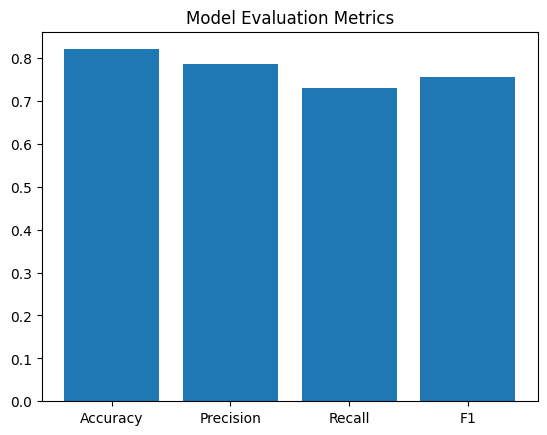

In [23]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [
    accuracy_scores.mean(),
    precision_scores.mean(),
    recall_scores.mean(),
    f1_scores.mean()
]

plt.bar(metrics, values)
plt.title("Model Evaluation Metrics")
plt.show()